# FinSight: Intelligent Personal Finance Analyzer
## Exploratory Data Analysis (EDA)

This notebook performs comprehensive exploratory data analysis on Indian personal finance data, examining spending patterns, income distribution, and savings potential.

## 1. Import Libraries and Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load the dataset
df = pd.read_csv('dataset/data.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (20000, 27)

First few rows:


,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076


## 2. Data Overview and Structure

In [4]:
# Display basic information
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("\nDataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Income                           20000 non-null  float64
 1   Age                              20000 non-null  int64  
 2   Dependents                       20000 non-null  int64  
 3   Occupation                       20000 non-null  str    
 4   City_Tier                        20000 non-null  str    
 5   Rent                             20000 non-null  float64
 6   Loan_Repayment                   20000 non-null  float64
 7   Insurance                        20000 non-null  float64
 8   Groceries                        20000 non-null  float64
 9   Transport                        20000 non-null  float64
 10  Eating_Out                       20000 non-null  float64
 11  Entertainment                    20000 non-null  float64
 12  Utilities      

In [5]:
# Check for missing values
print("Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")

# Display data types
print("\nData Types:")
print(df.dtypes)

Missing Values:
No missing values

Data Types:
Income                             float64
Age                                  int64
Dependents                           int64
Occupation                             str
City_Tier                              str
Rent                               float64
Loan_Repayment                     float64
Insurance                          float64
Groceries                          float64
Transport                          float64
Eating_Out                         float64
Entertainment                      float64
Utilities                          float64
Healthcare                         float64
Education                          float64
Miscellaneous                      float64
Desired_Savings_Percentage         float64
Desired_Savings                    float64
Disposable_Income                  float64
Potential_Savings_Groceries        float64
Potential_Savings_Transport        float64
Potential_Savings_Eating_Out       float64
Potenti

## 3. Statistical Summary

In [6]:
# Descriptive statistics
print("Descriptive Statistics:")
df.describe().round(2)

Descriptive Statistics:


,Income,Age,Dependents,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
count,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,...,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00
mean,41585.50,41.03,2.00,9115.49,2049.80,1455.03,5205.67,2704.47,1461.86,1448.85,...,4982.88,10647.37,912.20,473.04,254.96,254.03,436.33,41.52,62.42,144.90
std,40014.54,13.58,1.42,9254.23,4281.79,1492.94,5035.95,2666.35,1481.66,1489.02,...,7733.47,11740.64,1038.88,537.22,296.05,299.97,503.20,53.15,98.84,169.16
min,1301.19,18.00,0.00,235.37,0.00,30.00,154.08,81.23,39.44,45.42,...,0.00,-5400.79,16.58,8.27,3.80,3.12,6.20,0.00,0.00,2.09
25%,17604.88,29.00,1.00,3649.42,0.00,580.20,2165.43,1124.58,581.01,581.63,...,1224.93,3774.89,317.81,161.91,84.51,84.56,148.01,11.04,4.93,47.64
50%,30185.38,41.00,2.00,6402.75,0.00,1017.12,3741.09,1933.85,1029.11,1020.20,...,2155.36,7224.89,607.04,307.05,164.93,164.74,285.74,25.20,33.13,93.09
75%,51765.45,53.00,3.00,11263.94,2627.14,1787.16,6470.89,3360.60,1807.08,1790.10,...,6216.31,13331.95,1128.68,588.42,313.40,310.93,538.98,52.35,80.95,178.26
max,1079728.37,64.00,4.00,215945.67,123080.68,38734.93,119816.90,81861.50,34406.10,38667.37,...,245504.49,377060.22,34894.64,12273.26,5573.04,6222.20,8081.80,1394.53,3647.24,4637.95


In [7]:
# Income statistics
print("Income Statistics (in INR):")
print(f"Mean Income: ₹{df['Income'].mean():,.2f}")
print(f"Median Income: ₹{df['Income'].median():,.2f}")
print(f"Std Dev: ₹{df['Income'].std():,.2f}")
print(f"Min Income: ₹{df['Income'].min():,.2f}")
print(f"Max Income: ₹{df['Income'].max():,.2f}")

Income Statistics (in INR):
Mean Income: ₹41,585.50
Median Income: ₹30,185.38
Std Dev: ₹40,014.54
Min Income: ₹1,301.19
Max Income: ₹1,079,728.37


## 4. Expense Analysis

In [8]:
# Define expense categories
expense_categories = ['Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 
                      'Transport', 'Eating_Out', 'Entertainment', 'Utilities', 
                      'Healthcare', 'Education', 'Miscellaneous']

# Calculate total expenses
df['Total_Expenses'] = df[expense_categories].sum(axis=1)

print("Total Expenses Statistics (in INR):")
print(f"Mean Total Expenses: ₹{df['Total_Expenses'].mean():,.2f}")
print(f"Median Total Expenses: ₹{df['Total_Expenses'].median():,.2f}")
print(f"Std Dev: ₹{df['Total_Expenses'].std():,.2f}")
print(f"Min: ₹{df['Total_Expenses'].min():,.2f}")
print(f"Max: ₹{df['Total_Expenses'].max():,.2f}")

Total Expenses Statistics (in INR):
Mean Total Expenses: ₹30,938.13
Median Total Expenses: ₹22,258.04
Std Dev: ₹30,178.44
Min: ₹988.43
Max: ₹702,668.16


In [9]:
# Category-wise spending
category_spending = df[expense_categories].sum().sort_values(ascending=False)
print("\nTotal Spending by Category (in INR):")
for cat, amount in category_spending.items():
    pct = (amount / category_spending.sum()) * 100
    print(f"{cat:20s}: ₹{amount:>15,.0f} ({pct:>5.1f}%)")


Total Spending by Category (in INR):
Rent                : ₹    182,309,893 ( 29.5%)
Groceries           : ₹    104,113,350 ( 16.8%)
Transport           : ₹     54,089,334 (  8.7%)
Utilities           : ₹     50,099,539 (  8.1%)
Education           : ₹     49,966,968 (  8.1%)
Loan_Repayment      : ₹     40,996,006 (  6.6%)
Healthcare          : ₹     33,261,636 (  5.4%)
Eating_Out          : ₹     29,237,140 (  4.7%)
Insurance           : ₹     29,100,575 (  4.7%)
Entertainment       : ₹     28,977,073 (  4.7%)
Miscellaneous       : ₹     16,611,064 (  2.7%)


## 5. Visualizations - Expense Distribution

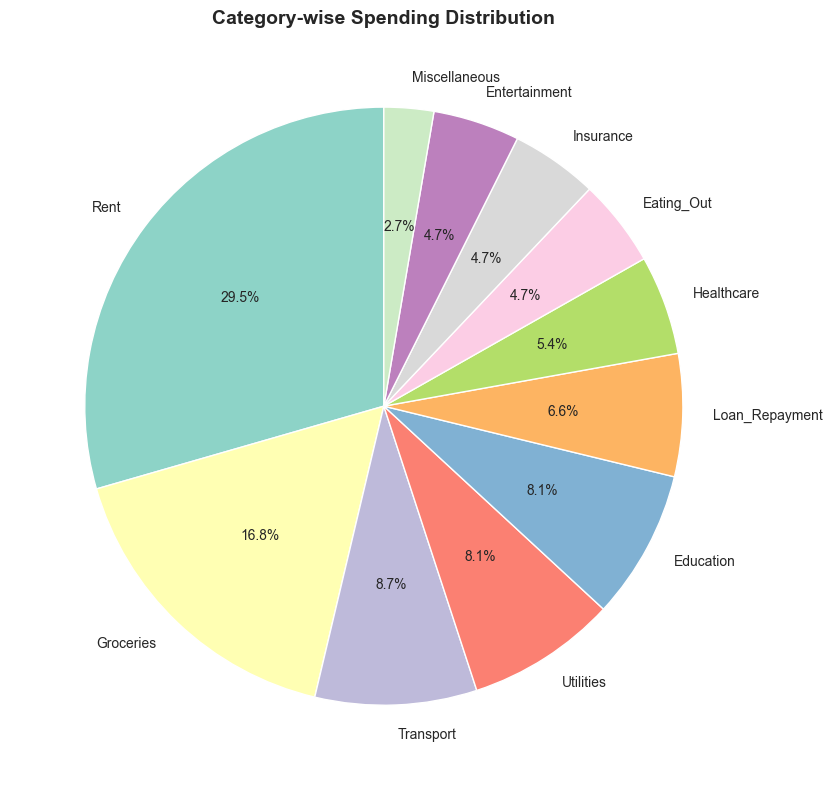

In [10]:
# Pie chart - Category-wise spending
fig, ax = plt.subplots(figsize=(12, 8))
colors = sns.color_palette('Set3', len(expense_categories))
ax.pie(category_spending.values, labels=category_spending.index, autopct='%1.1f%%',
       colors=colors, startangle=90)
ax.set_title('Category-wise Spending Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

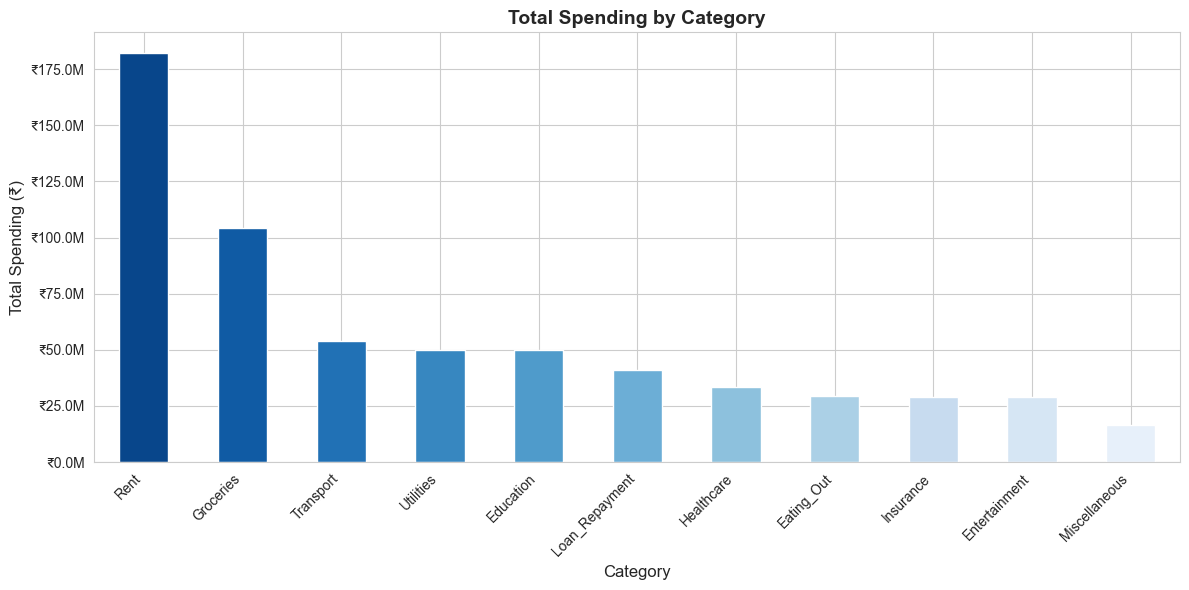

In [11]:
# Bar chart - Top spending categories
fig, ax = plt.subplots(figsize=(12, 6))
category_spending.plot(kind='bar', ax=ax, color=sns.color_palette('Blues_r', len(expense_categories)))
ax.set_title('Total Spending by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Total Spending (₹)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1e6:.1f}M'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Income vs Expenses Analysis

In [12]:
# Calculate expense ratio
df['Expense_Ratio'] = (df['Total_Expenses'] / df['Income']) * 100

print("Expense Ratio Analysis:")
print(f"Mean Expense Ratio: {df['Expense_Ratio'].mean():.2f}%")
print(f"Median Expense Ratio: {df['Expense_Ratio'].median():.2f}%")
print(f"Min: {df['Expense_Ratio'].min():.2f}%")
print(f"Max: {df['Expense_Ratio'].max():.2f}%")

# Savings analysis
print(f"\nAverage Disposable Income: ₹{df['Disposable_Income'].mean():,.2f}")
print(f"Total Disposable Income: ₹{df['Disposable_Income'].sum():,.0f}")

Expense Ratio Analysis:
Mean Expense Ratio: 74.49%
Median Expense Ratio: 73.51%
Min: 49.35%
Max: 106.24%

Average Disposable Income: ₹10,647.37
Total Disposable Income: ₹212,947,345


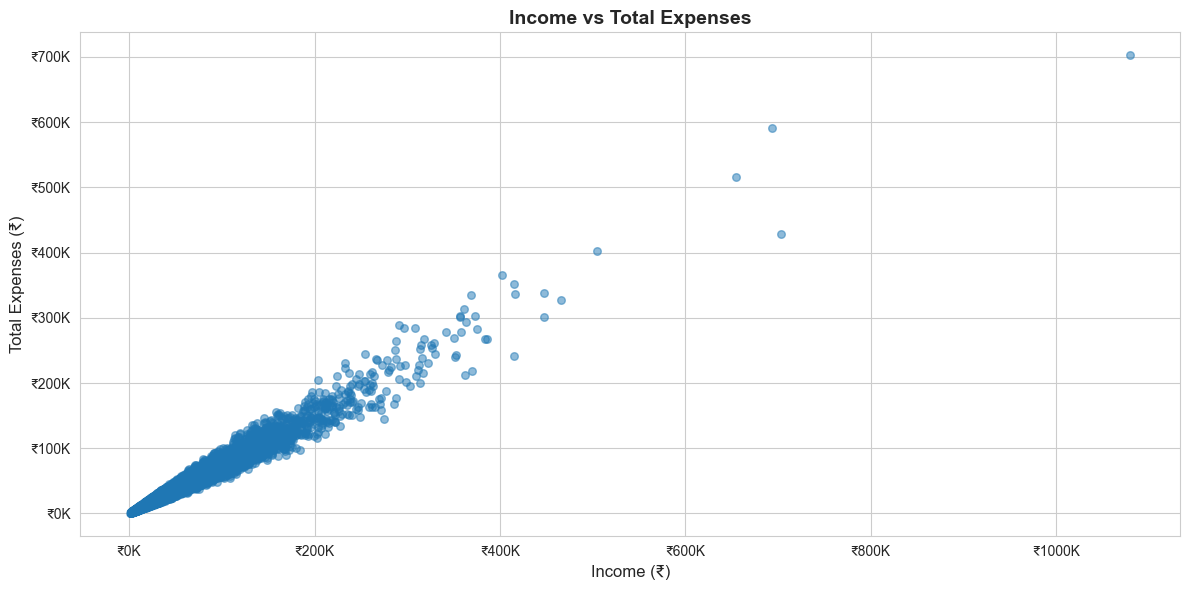

In [13]:
# Scatter plot - Income vs Total Expenses
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df['Income'], df['Total_Expenses'], alpha=0.5, s=30)
ax.set_xlabel('Income (₹)', fontsize=12)
ax.set_ylabel('Total Expenses (₹)', fontsize=12)
ax.set_title('Income vs Total Expenses', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1e3:.0f}K'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1e3:.0f}K'))
plt.tight_layout()
plt.show()

## 7. Demographic Analysis

In [14]:
# Occupation analysis
print("Occupation Distribution:")
occ_dist = df['Occupation'].value_counts()
print(occ_dist)

print("\nAverage Spending by Occupation:")
occ_spending = df.groupby('Occupation')['Total_Expenses'].mean().sort_values(ascending=False)
for occ, amount in occ_spending.items():
    print(f"{occ:20s}: ₹{amount:>10,.2f}")

Occupation Distribution:
Occupation
Retired          5019
Professional     5011
Student          5003
Self_Employed    4967
Name: count, dtype: int64

Average Spending by Occupation:
Professional        : ₹ 31,232.29
Self_Employed       : ₹ 31,185.28
Student             : ₹ 31,089.84
Retired             : ₹ 30,248.63


In [15]:
# City tier analysis
print("City Tier Distribution:")
city_dist = df['City_Tier'].value_counts()
print(city_dist)

print("\nAverage Spending by City Tier:")
city_spending = df.groupby('City_Tier')['Total_Expenses'].mean().sort_values(ascending=False)
for city, amount in city_spending.items():
    print(f"{city:20s}: ₹{amount:>10,.2f}")

City Tier Distribution:
City_Tier
Tier_2    10068
Tier_1     5934
Tier_3     3998
Name: count, dtype: int64

Average Spending by City Tier:
Tier_1              : ₹ 33,912.49
Tier_2              : ₹ 30,227.25
Tier_3              : ₹ 28,313.64


In [16]:
# Age analysis
print("Age Statistics:")
print(f"Mean Age: {df['Age'].mean():.1f} years")
print(f"Median Age: {df['Age'].median():.1f} years")
print(f"Age Range: {df['Age'].min()} - {df['Age'].max()} years")

print("\nDependents Statistics:")
print(f"Mean Dependents: {df['Dependents'].mean():.2f}")
print(f"Max Dependents: {df['Dependents'].max():.0f}")

Age Statistics:
Mean Age: 41.0 years
Median Age: 41.0 years
Age Range: 18 - 64 years

Dependents Statistics:
Mean Dependents: 2.00
Max Dependents: 4


## 8. Visualizations - Demographic Insights

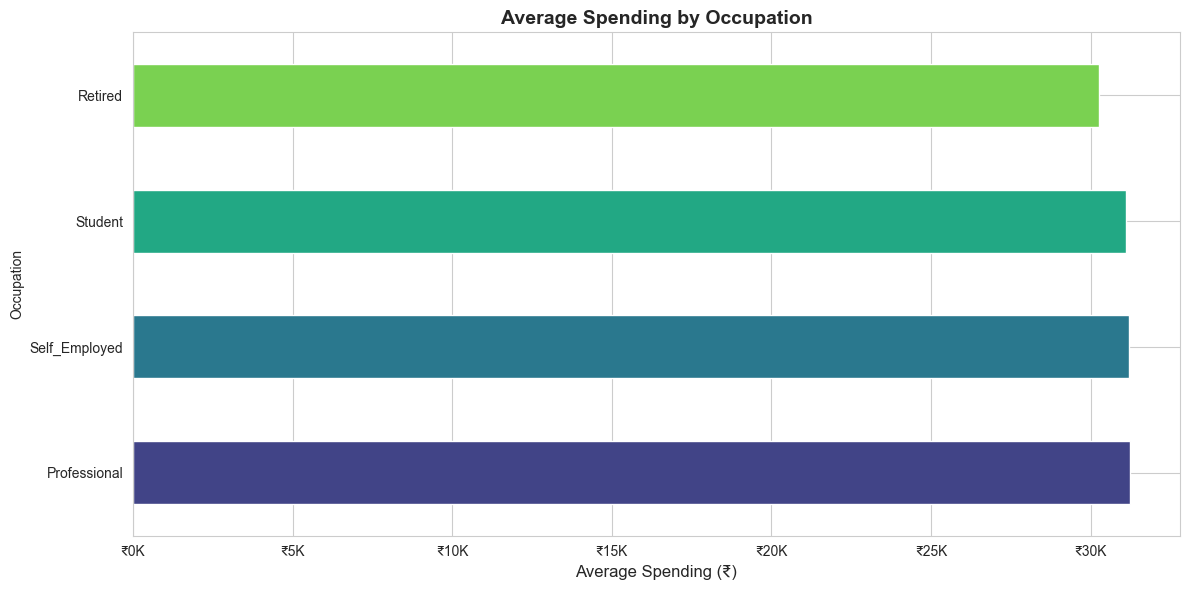

In [17]:
# Occupation-wise spending
fig, ax = plt.subplots(figsize=(12, 6))
occ_spending.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(occ_spending)))
ax.set_title('Average Spending by Occupation', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Spending (₹)', fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1e3:.0f}K'))
plt.tight_layout()
plt.show()

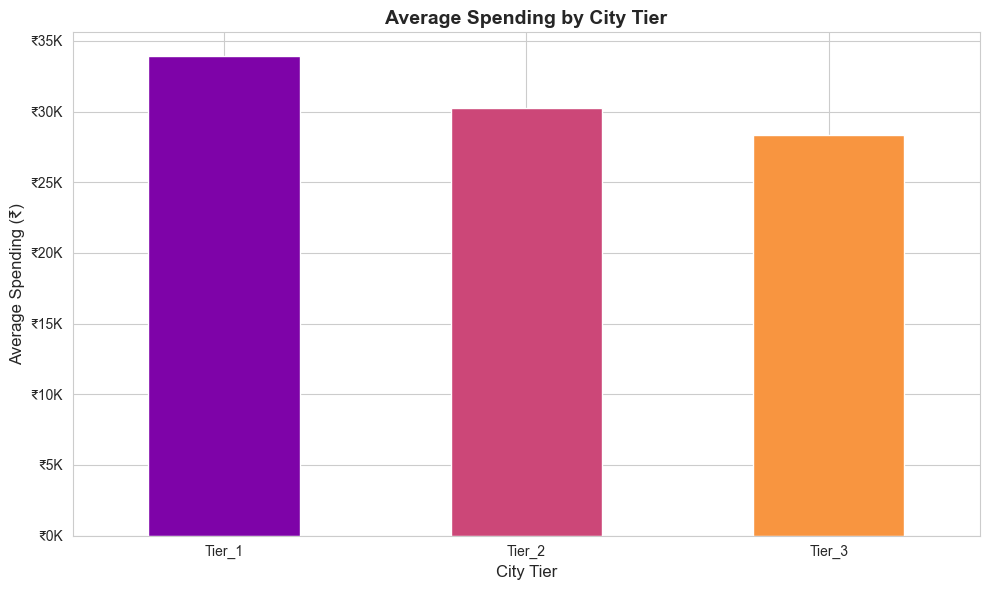

In [18]:
# City tier-wise spending
fig, ax = plt.subplots(figsize=(10, 6))
city_spending.plot(kind='bar', ax=ax, color=sns.color_palette('plasma', len(city_spending)))
ax.set_title('Average Spending by City Tier', fontsize=14, fontweight='bold')
ax.set_xlabel('City Tier', fontsize=12)
ax.set_ylabel('Average Spending (₹)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1e3:.0f}K'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

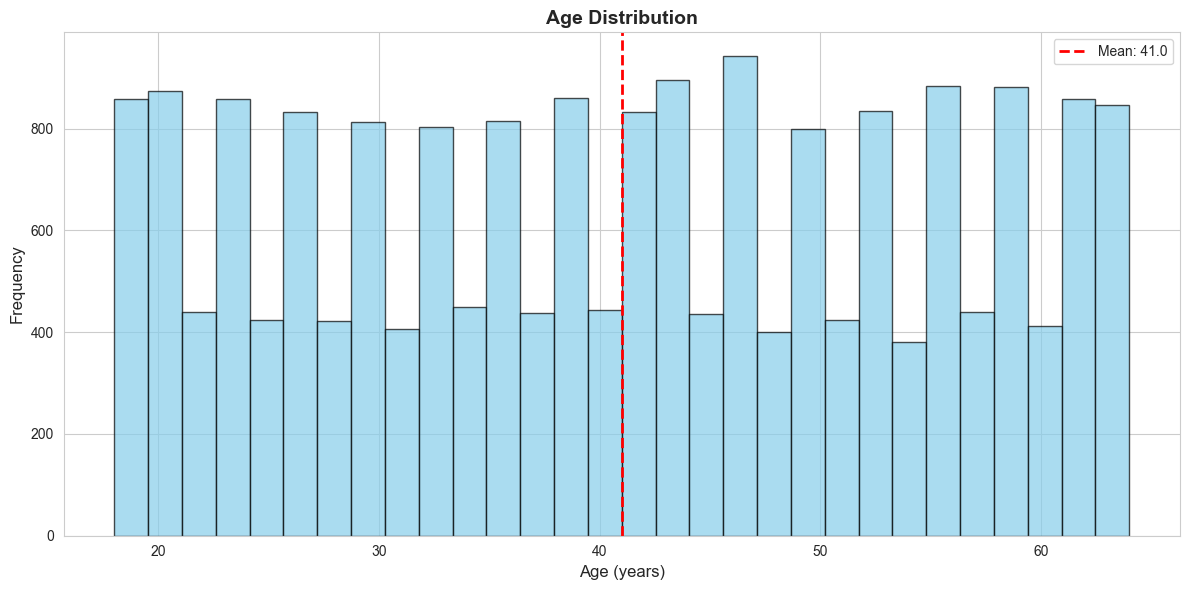

In [19]:
# Age distribution
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(df['Age'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax.set_title('Age Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Age"].mean():.1f}')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Savings Potential Analysis

In [20]:
# Identify potential savings columns
potential_savings_cols = [col for col in df.columns if 'Potential_Savings' in col]
print(f"Potential Savings Columns: {len(potential_savings_cols)}")
print(potential_savings_cols)

Potential Savings Columns: 8
['Potential_Savings_Groceries', 'Potential_Savings_Transport', 'Potential_Savings_Eating_Out', 'Potential_Savings_Entertainment', 'Potential_Savings_Utilities', 'Potential_Savings_Healthcare', 'Potential_Savings_Education', 'Potential_Savings_Miscellaneous']


In [21]:
# Calculate total potential savings
df['Total_Potential_Savings'] = df[potential_savings_cols].sum(axis=1)

print("Potential Savings Analysis (in INR):")
print(f"Total Potential Savings: ₹{df['Total_Potential_Savings'].sum():,.0f}")
print(f"Average per Person: ₹{df['Total_Potential_Savings'].mean():,.2f}")
print(f"Median: ₹{df['Total_Potential_Savings'].median():,.2f}")
print(f"Max: ₹{df['Total_Potential_Savings'].max():,.2f}")

Potential Savings Analysis (in INR):
Total Potential Savings: ₹51,588,280
Average per Person: ₹2,579.41
Median: ₹1,833.54
Max: ₹62,801.16


In [22]:
# Savings by category
savings_by_category = df[potential_savings_cols].sum().sort_values(ascending=False)
# Clean up column names
savings_by_category.index = [col.replace('Potential_Savings_', '') for col in savings_by_category.index]

print("\nPotential Savings by Category (in INR):")
for cat, amount in savings_by_category.items():
    pct = (amount / savings_by_category.sum()) * 100
    print(f"{cat:20s}: ₹{amount:>15,.0f} ({pct:>5.1f}%)")


Potential Savings by Category (in INR):
Groceries           : ₹     18,243,944 ( 35.4%)
Transport           : ₹      9,460,853 ( 18.3%)
Utilities           : ₹      8,726,656 ( 16.9%)
Eating_Out          : ₹      5,099,266 (  9.9%)
Entertainment       : ₹      5,080,621 (  9.8%)
Miscellaneous       : ₹      2,898,100 (  5.6%)
Education           : ₹      1,248,342 (  2.4%)
Healthcare          : ₹        830,499 (  1.6%)


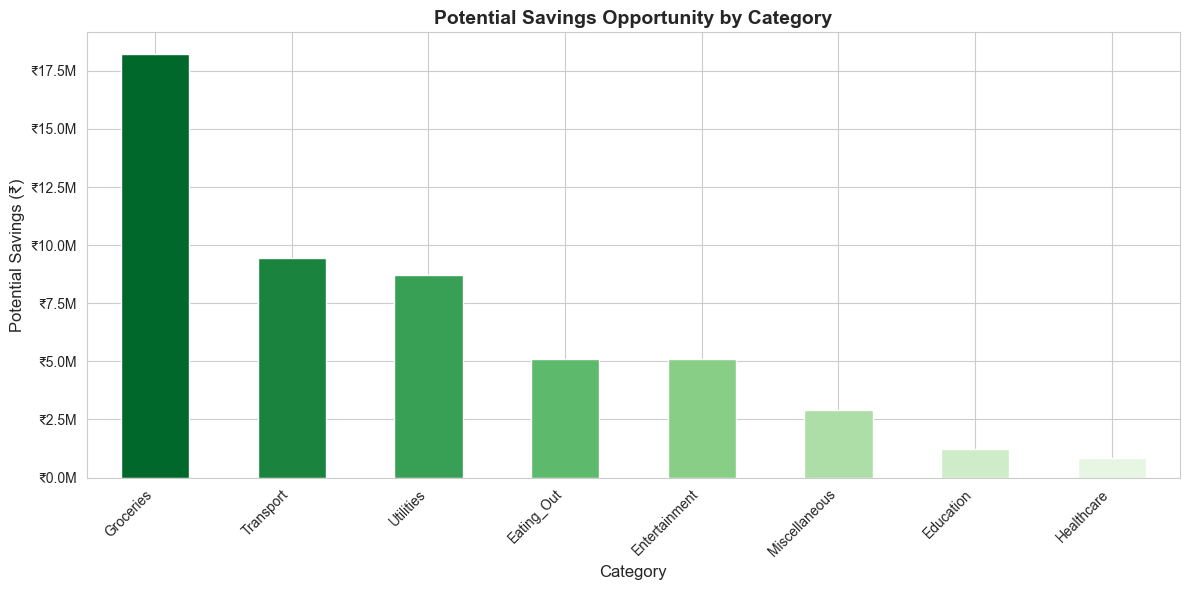

In [23]:
# Visualize potential savings
fig, ax = plt.subplots(figsize=(12, 6))
savings_by_category.plot(kind='bar', ax=ax, color=sns.color_palette('Greens_r', len(savings_by_category)))
ax.set_title('Potential Savings Opportunity by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Potential Savings (₹)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1e6:.1f}M'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10. Key Insights and Conclusions

In [24]:
print("="*60)
print("KEY INSIGHTS FROM FINSIGHT ANALYSIS")
print("="*60)

print(f"\n1. INCOME & EXPENSES:")
print(f"   - Average Monthly Income: ₹{df['Income'].mean():,.0f}")
print(f"   - Average Monthly Expenses: ₹{df['Total_Expenses'].mean():,.0f}")
print(f"   - Average Expense Ratio: {df['Expense_Ratio'].mean():.1f}%")

print(f"\n2. TOP SPENDING CATEGORIES:")
top_3 = category_spending.head(3)
for i, (cat, amount) in enumerate(top_3.items(), 1):
    pct = (amount / category_spending.sum()) * 100
    print(f"   {i}. {cat}: ₹{amount:,.0f} ({pct:.1f}%)")

print(f"\n3. SAVINGS POTENTIAL:")
print(f"   - Total Potential Savings: ₹{df['Total_Potential_Savings'].sum():,.0f}")
print(f"   - Average per Person: ₹{df['Total_Potential_Savings'].mean():,.0f}")
print(f"   - Percentage of Total Expenses: {(df['Total_Potential_Savings'].sum() / df['Total_Expenses'].sum() * 100):.1f}%")

print(f"\n4. DEMOGRAPHIC INSIGHTS:")
print(f"   - Average Age: {df['Age'].mean():.1f} years")
print(f"   - Average Dependents: {df['Dependents'].mean():.2f}")
print(f"   - Most Common Occupation: {df['Occupation'].value_counts().index[0]}")
print(f"   - Most Common City Tier: {df['City_Tier'].value_counts().index[0]}")

print(f"\n5. FINANCIAL HEALTH:")
print(f"   - Average Disposable Income: ₹{df['Disposable_Income'].mean():,.0f}")
print(f"   - People with Positive Disposable Income: {(df['Disposable_Income'] > 0).sum()} ({(df['Disposable_Income'] > 0).sum()/len(df)*100:.1f}%)")

print("\n" + "="*60)

KEY INSIGHTS FROM FINSIGHT ANALYSIS

1. INCOME & EXPENSES:
   - Average Monthly Income: ₹41,585
   - Average Monthly Expenses: ₹30,938
   - Average Expense Ratio: 74.5%

2. TOP SPENDING CATEGORIES:
   1. Rent: ₹182,309,893 (29.5%)
   2. Groceries: ₹104,113,350 (16.8%)
   3. Transport: ₹54,089,334 (8.7%)

3. SAVINGS POTENTIAL:
   - Total Potential Savings: ₹51,588,280
   - Average per Person: ₹2,579
   - Percentage of Total Expenses: 8.3%

4. DEMOGRAPHIC INSIGHTS:
   - Average Age: 41.0 years
   - Average Dependents: 2.00
   - Most Common Occupation: Retired
   - Most Common City Tier: Tier_2

5. FINANCIAL HEALTH:
   - Average Disposable Income: ₹10,647
   - People with Positive Disposable Income: 19888 (99.4%)



## 11. Recommendations

In [25]:
print("RECOMMENDATIONS FOR FINANCIAL OPTIMIZATION:")
print("\n1. Focus on High-Impact Categories:")
print(f"   - {category_spending.index[0]} accounts for {(category_spending.iloc[0]/category_spending.sum()*100):.1f}% of spending")
print(f"   - Even 10% reduction could save ₹{category_spending.iloc[0]*0.1:,.0f} per person monthly")

print(f"\n2. Leverage Savings Opportunities:")
print(f"   - Total identified savings potential: ₹{df['Total_Potential_Savings'].sum():,.0f}")
print(f"   - This represents {(df['Total_Potential_Savings'].sum() / df['Total_Expenses'].sum() * 100):.1f}% of total expenses")

print(f"\n3. Segment-Specific Strategies:")
highest_spending_occ = occ_spending.index[0]
print(f"   - {highest_spending_occ} has highest average spending (₹{occ_spending.iloc[0]:,.0f})")
print(f"   - Targeted interventions could yield significant savings")

print(f"\n4. Income-Expense Balance:")
print(f"   - Current average expense ratio: {df['Expense_Ratio'].mean():.1f}%")
print(f"   - Target: Reduce to 70-75% for better financial health")

RECOMMENDATIONS FOR FINANCIAL OPTIMIZATION:

1. Focus on High-Impact Categories:
   - Rent accounts for 29.5% of spending
   - Even 10% reduction could save ₹18,230,989 per person monthly

2. Leverage Savings Opportunities:
   - Total identified savings potential: ₹51,588,280
   - This represents 8.3% of total expenses

3. Segment-Specific Strategies:
   - Professional has highest average spending (₹31,232)
   - Targeted interventions could yield significant savings

4. Income-Expense Balance:
   - Current average expense ratio: 74.5%
   - Target: Reduce to 70-75% for better financial health
